# Phase 2 - Exploratory Data Analysis

## Healthcare AI System

**Input**: `outputs/model_table.csv` — 25,000 rows, 20 columns\
**Output**: `Engineered model_table.csv` ready for Phase 3 Modeling

## EDA Philosophy: What Architects Look For
A data scientist asks: "What does the data look like?"\
An architect asks: "What will this data do to my model?"

These are four questions every architect answers before touching a model:

**1. Are the labels meaningful?**\
If labels are random, no model can learn them. Period.

**2. Is there class imbalance?**\
Imbalance causes models to ignore minority classes entirely — called class collapse.

**3. Which features have real signal?**\
Correlation tells us where to focus feature engineering effort.

**4. Are outliers errors or reality?**\
In healthcare, extreme values are often the most important rows.

The answers to these four questions shape every modeling decision we make in Phase 3.

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
# Load Model Tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
# Convert date columns
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] = pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

## Distribution Analysis
### Step 1 - Missing Values Analysis
First thing we always check — what is missing and why.\
Not all nulls are data errors. Some are business logic.

In [4]:
# Overall null check
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
claim_status               0
billed_amount              0
bill_id                    0
doctor_id                  0
risk_score                 0
length_of_stay_hours       0
visit_type                 0
department                 0
visit_date                 0
visit_id                   0
registration_date          0
chronic_flag               0
insurance_provider         0
city                       0
gender                     0
billing_date               0
dtype: int64

In [5]:
# Focus on key columns 
df[["approved_amount", "payment_days","length_of_stay_hours"]].isnull().sum()

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

### Step 2 — Business Logic Validation
Three checks before we touch any model.\
We are validating that the data makes **business sense** — not just statistical sense.

In [6]:
# Check A - paid claims should always have an approved amount
# if this returns 0, then we are clean

df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(817, 20)

In [7]:
 # Check B - payment days missing breakdown by claim status
df[(df["payment_days"].isna())]["claim_status"].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

In [8]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

np.int64(0)

### Step 3 — Distribution Analysis
We look at every important column — categorical and numeric.\
Goal: understand the shape of our data before building any model.

In [9]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

======Visit Type=================
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

=======City=======================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


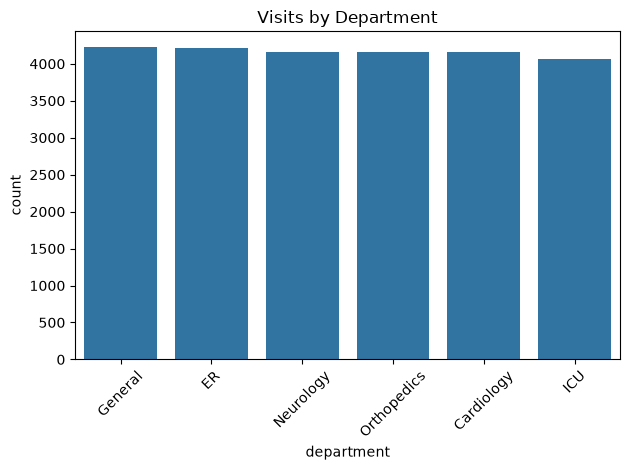

In [10]:
# Bar chart showing vsits by department
sns.countplot(data=df, x="department", order=df['department'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

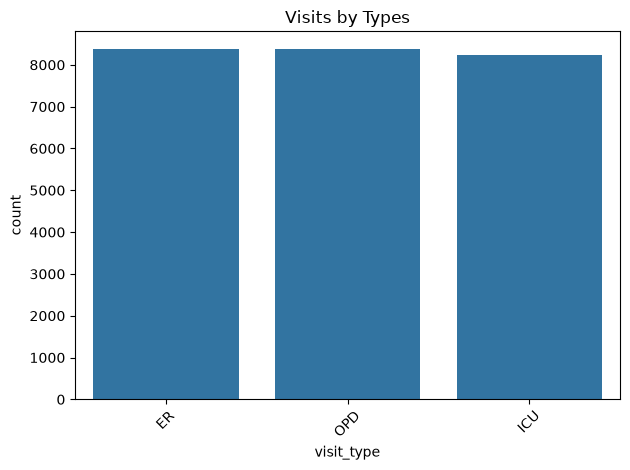

In [11]:
# Bar chart showing vsits by types
sns.countplot(data=df, x="visit_type", order=df['visit_type'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Types")
plt.tight_layout()
plt.show()

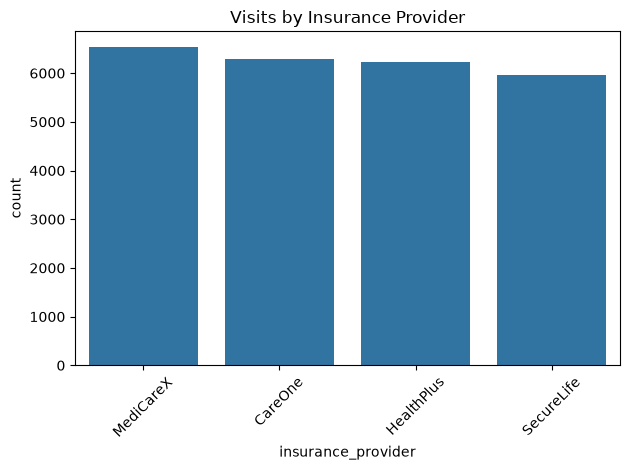

In [12]:
# Bar chart showing vsits by Insurance Providers
sns.countplot(data=df, x="insurance_provider", order=df['insurance_provider'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Insurance Provider")
plt.tight_layout()
plt.show()

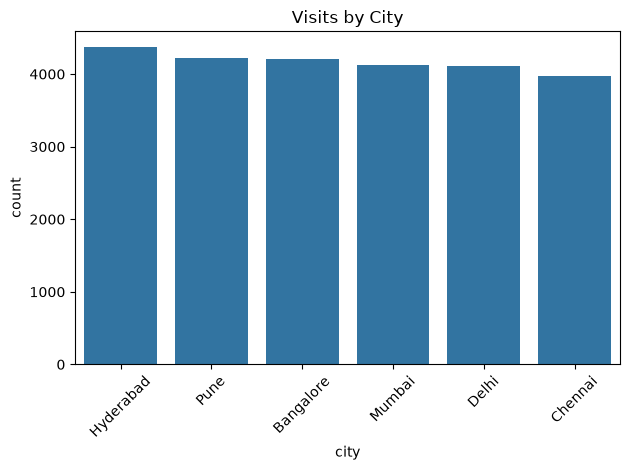

In [13]:
# Bar chart showing vsits by City
sns.countplot(data=df, x="city", order=df['city'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by City")
plt.tight_layout()
plt.show()

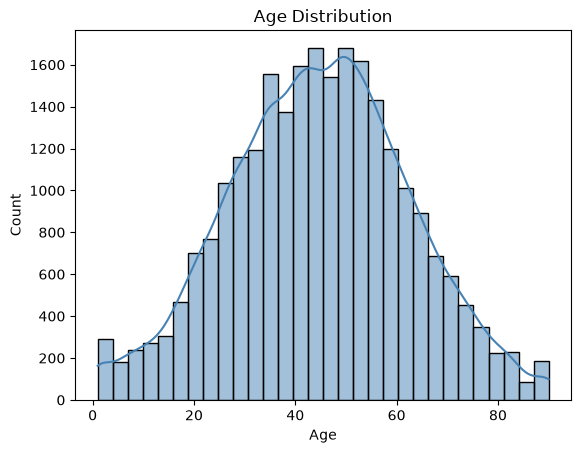

count    25000.00
mean        44.77
std         17.78
min          1.00
25%         33.00
50%         45.00
75%         57.00
max         90.00
Name: age, dtype: float64


In [14]:
# Age Distribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe().round(2))

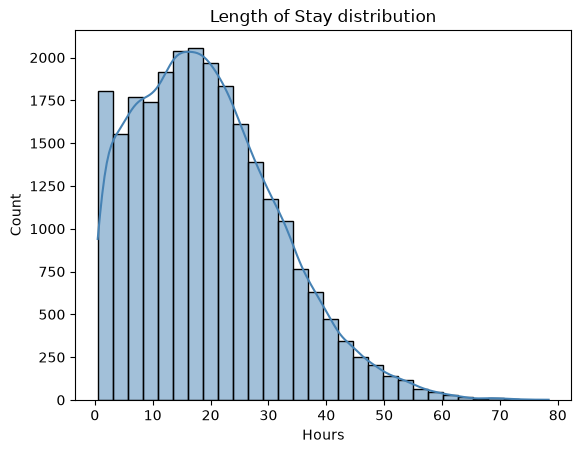

count    25000.00
mean        19.55
std         12.31
min          0.50
25%          9.96
50%         18.20
75%         27.31
max         78.42
Name: length_of_stay_hours, dtype: float64


In [15]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay distribution")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [16]:
"""
IQR = Interquartile Range - the spread of the middle 50% of your data
25% = 9.96  (bottom quarter boundary)
75% = 27.31 (top quarter boundary)
"""
IQR = 27.31 - 9.96
print(IQR)

17.349999999999998


In [17]:
# Upper Fence
"""
An upper fence is the cutoff, beyond which a value is considered to an outlier
upper_fence = 75% + (1.5*IQR)
John's variable = 1.5 (universal multiplier)
"""
upper_fence = 27.31 + (1.5 * IQR)
print(upper_fence)

53.334999999999994


## Outlier Detection
### Step 4 — Outlier Detection
Two approaches:

* **Boxplot** — visual detection
* **IQR method** — numerical calculation
**IQR = Q3 − Q1** (middle 50% of data)

Lower bound = Q1 − 1.5 × IQR\
Upper bound = Q3 + 1.5 × IQR

Anything outside these bounds = outlier.

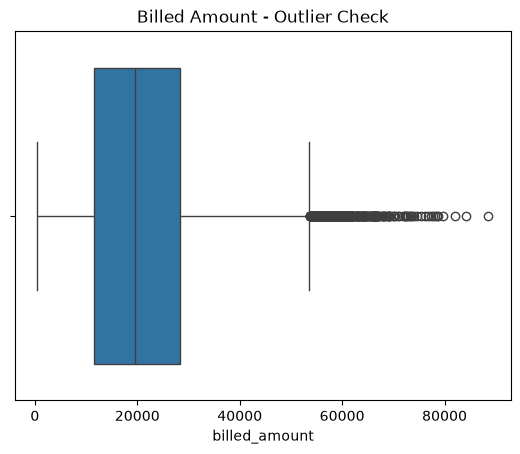

In [18]:
# Billed Amount  Outlier Check
sns.boxplot(x=df["billed_amount"])
plt.title("Billed Amount - Outlier Check")
plt.show()

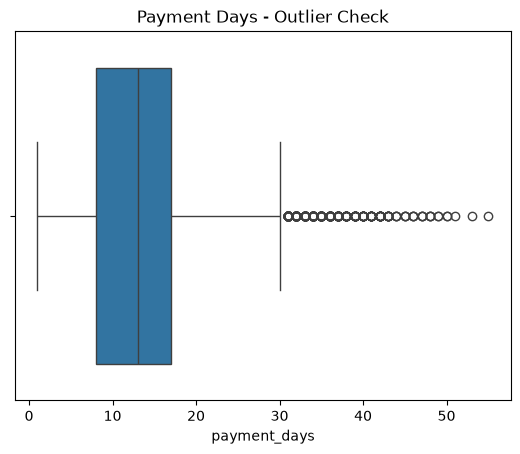

In [19]:
# Payment Days outlier check
sns.boxplot(x=df['payment_days'])
plt.title("Payment Days - Outlier Check")
plt.show()

Text(0.5, 1.0, 'Length of Stays - Outlier Check')

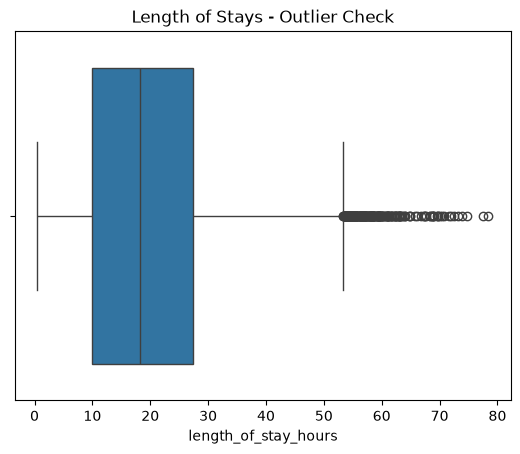

In [20]:
# LEngth of Stays outlier check
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stays - Outlier Check")

In [21]:
# IQR explicit calculation — numbers behind the boxplot
for col in ["length_of_stay_hours", "payment_days", "billed_amount"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col}")
    print(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    print(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    print(f"  Outliers    = {n_out} rows")
    print()

length_of_stay_hours
  Q1 = 10.0  |  Q3 = 27.3  |  IQR = 17.4
  Lower bound = -16.1  |  Upper bound = 53.3
  Outliers    = 256 rows

payment_days
  Q1 = 8.0  |  Q3 = 17.0  |  IQR = 9.0
  Lower bound = -5.5  |  Upper bound = 30.5
  Outliers    = 509 rows

billed_amount
  Q1 = 11582.5  |  Q3 = 28398.1  |  IQR = 16815.6
  Lower bound = -13641.0  |  Upper bound = 53621.5
  Outliers    = 373 rows



## Feature Correlations
### Step 5 — Feature Correlations
We encode the target variables numerically so we can measure correlation.

* `risk_score` → Low=0, Medium=1, High=2
* `claim_status` → Paid=0, Pending=1, Rejected=2

In [22]:
# Encode target for correlation analysis
df["risk_numeric"] = df["risk_score"].map(
    {"Low": 0, "Medium": 1, "High": 2}
)
df["claim_numeric"] = df["claim_status"].map(
    {"Paid": 0, "Pending": 1, "Rejected": 2}
)
print("risk_numeric: ",{"Low": 0, "Medium": 1, "High": 2})
print("claim_numeric: ",{"Paid": 0, "Pending": 1, "Rejected": 2})

risk_numeric:  {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric:  {'Paid': 0, 'Pending': 1, 'Rejected': 2}


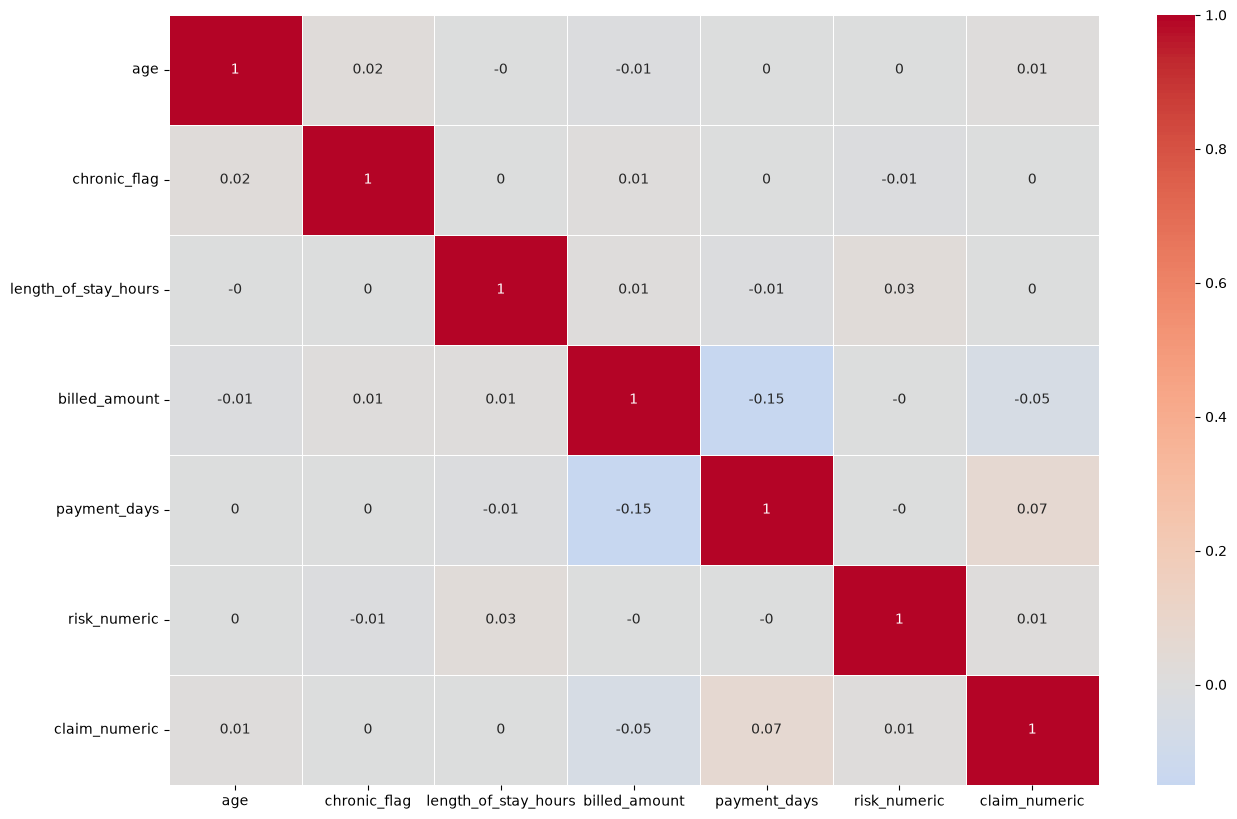

In [23]:
# Full correlation matrix
numeric_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_numeric"
]
corr = df[numeric_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            )

In [24]:
# What correlates with risk_score?
corr_risk = corr["risk_numeric"].drop("risk_numeric")

print("Correlation with risk_score (sorted):")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted):
length_of_stay_hours    0.03
claim_numeric           0.01
age                     0.00
billed_amount          -0.00
payment_days           -0.00
chronic_flag           -0.01
Name: risk_numeric, dtype: float64


In [25]:
# What correlates with claim_status?
corr_claim = corr["claim_numeric"].drop("claim_numeric")

print("Correlation with claim_status (sorted):")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted):
payment_days            0.07
age                     0.01
risk_numeric            0.01
chronic_flag            0.00
length_of_stay_hours    0.00
billed_amount          -0.05
Name: claim_numeric, dtype: float64


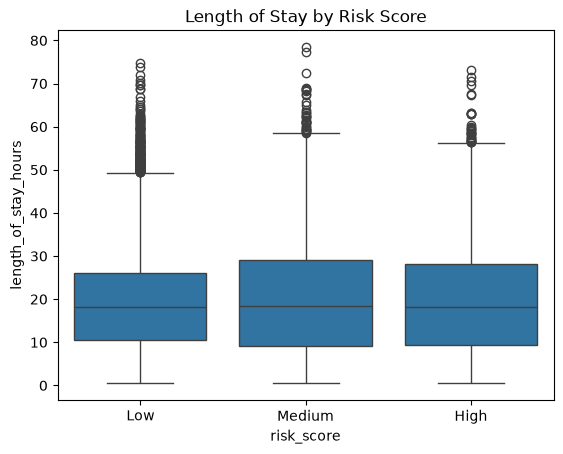


Mean LOS by Risk Score:
risk_score
High      19.76
Low       19.15
Medium    20.08
Name: length_of_stay_hours, dtype: float64


In [26]:
# LOS by risk score — the most important relationship
sns.boxplot(data=df, x="risk_score", y="length_of_stay_hours",
            order=["Low", "Medium", "High"])
plt.title("Length of Stay by Risk Score")
plt.show()

print("\nMean LOS by Risk Score:")
print(df.groupby("risk_score")["length_of_stay_hours"]
      .mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
SecureLife    15.7
MediCareX     15.2
HealthPlus    15.0
CareOne       14.9
Name: is_rejected, dtype: float64


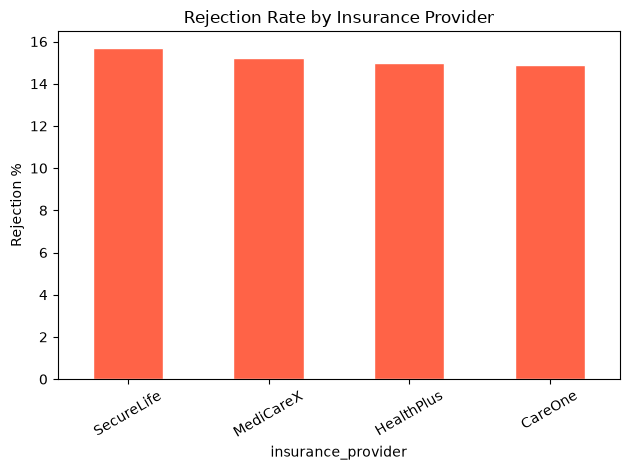

In [27]:
# Rejection rate by insurance provider
df["is_rejected"] = (df["claim_status"] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"]
            .mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Class Imbalance Deep Dive
### Step 6 — Class Imbalance & Class Collapse Demo
**Class imbalance** = one class has significantly more rows than others.

**Class collapse** = the model ignores minority classes and predicts only the majority class — achieving decent accuracy by being lazy.

We will prove this live with a before/after demo.

In [28]:
# Naive baseline - what happens if we always predict majority class
most_common = df["risk_score"].mode()[0]
naive_acc = (df["risk_score"] == most_common).mean()
print(f"Majority class: '{most_common}'") 
print(f"Naive Accuracy: '{naive_acc:.1%}'")

Majority class: 'Low'
Naive Accuracy: '49.9%'


In [ ]:
# Demo setup - two features only, to keep it clean
X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
y_demo = df["risk_score"]

# without class weight
model_bad = LogisticRegression(max_iter=1000, random_state=42) # Creating the brain
model_bad.fit(X_demo, y_demo) # Training the brain
pred_bad = model_bad.predict(X_demo) # Using the brain
print("Without class_weight='balanced':")
print("-"*45)
print(classification_report(y_demo, pred_bad))

Without class_weight='balanced':
---------------------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      5034
         Low       0.50      1.00      0.67     12470
      Medium       0.00      0.00      0.00      7496

    accuracy                           0.50     25000
   macro avg       0.17      0.33      0.22     25000
weighted avg       0.25      0.50      0.33     25000



In [ ]:
# Demo setup - two features only, to keep it clean
#X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
#y_demo = df["risk_score"]

# without class weight
model_good = LogisticRegression(max_iter=1000,class_weight="balanced", random_state=42) # Creating the brain
model_good.fit(X_demo, y_demo) # Training the brain
pred_good = model_good.predict(X_demo) # Using the brain
print("With class_weight='balanced':")
print("-"*53)
print(classification_report(y_demo, pred_good))

With class_weight='balanced':
-----------------------------------------------------
              precision    recall  f1-score   support

        High       0.19      0.20      0.20      5034
         Low       0.50      0.46      0.48     12470
      Medium       0.32      0.35      0.34      7496

    accuracy                           0.37     25000
   macro avg       0.34      0.34      0.34     25000
weighted avg       0.38      0.37      0.38     25000



## Step 7 — Feature Engineering

We create 7 new features from the existing columns.  
These features encode **patient behaviour** and **provider patterns**  
that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
|---|---|---|
| days_since_registration | visit_date − registration_date | Long-term patients behave differently |
| visit_frequency | count of visits per patient | Frequent visitors = higher utilisation |
| avg_los_per_patient | mean LOS per patient | Patient-level health baseline |
| is_rejected | 1 if Rejected else 0 | Helper for rejection rate |
| provider_rejection_rate | mean rejection per insurer | Encodes insurer behaviour |
| visit_month | month from visit_date | Seasonality signal |
| visit_dayofweek | day of week from visit_date | Operational pattern |
| high_cost_visit_flag | billed > 75th percentile | Flags expensive visits |

In [32]:
# Days since registration
df["days_since_registration"] = abs(
    df["visit_date"] - df["registration_date"]
).dt.days

df[["patient_id", "visit_date",
    "registration_date", "days_since_registration"]].head()

,patient_id,visit_date,registration_date,days_since_registration
0,3993,2025-01-20,2025-10-18,271
1,76,2025-01-20,2025-07-09,170
2,3393,2025-01-20,2025-07-10,171
3,1998,2025-01-20,2025-04-22,92
4,3500,2025-01-20,2025-08-02,194


In [33]:
# Visit frequency per patient
df["visit_frequency"] = df.groupby("patient_id")["visit_id"].transform("count")

df[["patient_id", "visit_frequency"]].drop_duplicates().head(10)

,patient_id,visit_frequency
0,3993,4
1,76,5
2,3393,8
3,1998,11
4,3500,7
5,3286,7
6,152,5
7,532,6
8,4451,7
9,2826,7


In [34]:
# Average LOS per patient
df["avg_los_per_patient"] = df.groupby("patient_id")["length_of_stay_hours"].transform("mean")

df[["patient_id", "length_of_stay_hours",
    "avg_los_per_patient"]].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,3993,5.79,12.645000
1,76,34.80,22.330000
2,3393,31.37,24.091250
3,1998,20.88,18.974545
4,3500,4.97,21.358571


In [35]:
# Provider rejection rate
# is_rejected already created in Cell 37
df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

print("Rejection rate per provider:")
print(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

Rejection rate per provider:
insurance_provider
CareOne       0.149
HealthPlus    0.150
MediCareX     0.152
SecureLife    0.157
Name: provider_rejection_rate, dtype: float64


In [36]:
# Time-based features
df["visit_month"]      = df["visit_date"].dt.month
df["visit_dayofweek"]  = df["visit_date"].dt.dayofweek

df[["visit_date", "visit_month", "visit_dayofweek"]].head()

,visit_date,visit_month,visit_dayofweek
0,2025-01-20,1,0
1,2025-01-20,1,0
2,2025-01-20,1,0
3,2025-01-20,1,0
4,2025-01-20,1,0


In [37]:
# High cost visit flag — top 25% of billed amount
high_cost_threshold = df["billed_amount"].quantile(0.75)
df["high_cost_visit_flag"] = (df["billed_amount"] > high_cost_threshold).astype(int)

print(f"High cost threshold (75th percentile): ₹{high_cost_threshold:,.0f}")
print()
print(df["high_cost_visit_flag"].value_counts())

High cost threshold (75th percentile): ₹28,398

high_cost_visit_flag
0    18750
1     6250
Name: count, dtype: int64


In [38]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added:")
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added:
  ✓ days_since_registration
  ✓ visit_frequency
  ✓ avg_los_per_patient
  ✓ provider_rejection_rate
  ✓ visit_month
  ✓ visit_dayofweek
  ✓ high_cost_visit_flag

Final dataset shape: (25000, 30)


In [39]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.0,25000.00
mean,121.13,5.96,19.55,0.15,6.52,3.0,0.25
std,86.28,2.18,5.51,0.00,3.46,2.0,0.43
min,0.00,1.00,0.50,0.15,1.00,0.0,0.00
25%,48.00,4.00,15.93,0.15,4.00,1.0,0.00
50%,106.00,6.00,19.20,0.15,7.00,3.0,0.00
75%,183.00,7.00,22.84,0.15,10.00,5.0,0.25
max,364.00,15.00,56.23,0.16,12.00,6.0,1.00


In [ ]:
# Save enriched model_table — ready for Phase 3 Modeling
df.to_csv("../outputs/model_table.csv", index=False)

print("model_table.csv saved ✓")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nReady for Phase 3 — Modeling")